In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: Install Dependencies
# ══════════════════════════════════════════════════════════════════════════════
# Run once then restart the kernel.
#
#   langchain        — core LLM application framework
#   langgraph        — graph-based agent orchestration (ReAct loop)
#   langchain-google-genai — Gemini LLM integration
#   tavily-python    — LLM-optimized web search client
# ══════════════════════════════════════════════════════════════════════════════

# !pip install langchain>=0.3.0 langgraph>=0.2.0 langchain-google-genai>=2.1.4,<3.0.0 tavily-python>=0.5.0

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: Imports and Environment Setup
# ══════════════════════════════════════════════════════════════════════════════
#
# Key imports:
#   TypedDict / Annotated  — typed agent state schema
#   StateGraph / ToolNode  — LangGraph graph construction primitives
#   ChatGoogleGenerativeAI — Gemini LLM used for reasoning
#   get_sync_engine        — PortalPoint DB engine (SQLAlchemy, reads DATABASE_URL)
#
# sys.path is extended so portalpoint can be imported from within the notebook
# without a full package install step.
# ══════════════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

import os
import sys
import json
from pathlib import Path
from datetime import datetime, date as _date
from typing import TypedDict, Annotated, Literal, Optional

# LangChain core
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage, SystemMessage
from langchain_core.tools import tool

# LangGraph agent orchestration
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Gemini LLM
from langchain_google_genai import ChatGoogleGenerativeAI

# Tavily web search (reads TAVILY_API_KEY from env)
from tavily import TavilyClient


# ── Locate repo root and extend sys.path ─────────────────────────────────────
def find_repo_root() -> Path:
    """Walk up from cwd to find the repo root (contains pyproject.toml)."""
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError("Could not find repo root (no pyproject.toml found)")

def load_env(path: Path = None) -> dict:
    """Load .env file into os.environ and return as dict."""
    p = path or (find_repo_root() / '.env')
    env = {}
    if not p.exists():
        print(f"Warning: .env file not found at {p}")
        return env
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        env[k.strip()] = v.strip()
        os.environ[k.strip()] = v.strip()
    return env

REPO_ROOT = find_repo_root()

# Make portalpoint importable without a separate install step
_src_path = str(REPO_ROOT / 'src')
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)

# Make scripts importable (for name normalization functions)
_scripts_path = str(REPO_ROOT / 'scripts')
if _scripts_path not in sys.path:
    sys.path.insert(0, _scripts_path)

_env = load_env()

# ── PortalPoint DB engine ─────────────────────────────────────────────────────
# get_sync_engine reads DATABASE_URL from the environment.
# If DATABASE_URL is not set, transfer_player will catch the error gracefully.
try:
    from portalpoint.modeling.io import get_sync_engine
    _db_available = True
    print("✓ portalpoint DB engine imported")
except ImportError as e:
    _db_available = False
    get_sync_engine = None  # type: ignore
    print(f"⚠️  portalpoint import failed: {e}")
    print("   transfer_player will return errors — DB updates require portalpoint installed")

# ── Name normalization from ingestion pipeline ────────────────────────────────
# Reuse the battle-tested matching logic from ingest_transfers_247sports.py:
#   _normalize_name  — lowercase, strip accents, strip Jr./Sr./II/III suffixes
#   _resolve_school  — alias lookup + difflib fuzzy match
#   SCHOOL_ALIASES   — canonical name mappings (Penn State → Penn St., etc.)
try:
    from ingest_transfers_247sports import (
        _normalize_name,
        _resolve_school,
        SCHOOL_ALIASES,
    )
    _normalization_available = True
    print(f"✓ Name normalization imported ({len(SCHOOL_ALIASES)} school aliases)")
except ImportError as e:
    _normalization_available = False
    _normalize_name = None  # type: ignore
    _resolve_school = None  # type: ignore
    SCHOOL_ALIASES = {}
    print(f"⚠️  Name normalization import failed: {e}")
    print("   transfer_player will fall back to simple ILIKE matching")

# ── Verify API keys ───────────────────────────────────────────────────────────
GOOGLE_API_KEY = os.environ.get('GOOGLE_API_KEY')
if not GOOGLE_API_KEY:
    print("⚠️  GOOGLE_API_KEY not set — add to .env")
else:
    print(f"✓ GOOGLE_API_KEY loaded (ends with ...{GOOGLE_API_KEY[-4:]})")

print(f"✓ Repo root: {REPO_ROOT}")
print("✓ Imports OK")

✓ portalpoint DB engine imported
✓ Name normalization imported (31 school aliases)
✓ GOOGLE_API_KEY loaded (ends with ...zWkA)
✓ Repo root: C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone
✓ Imports OK


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: Agent State Schema
# ══════════════════════════════════════════════════════════════════════════════
#
# STATE MANAGEMENT IN LANGGRAPH
# ═══════════════════════════════════════════════════════════════════════════════
# Every node reads from and writes to this TypedDict. Literal types on
# event_type give the LLM a closed set of categories and enable type-safe
# conditional routing (player_enters_portal → transfer_player tool,
# coach_leaves → coach_departure tool).
#
# portal_updates tracks the DB writes made this run (one entry per player
# successfully marked as a portal candidate).
# ══════════════════════════════════════════════════════════════════════════════

EventType = Literal[
    "player_enters_portal",  # → routes to transfer_player tool
    "coach_leaves",          # → routes to coach_departure tool
    "unknown"                # → no action taken
]


class DetectedEvent(TypedDict):
    """
    Structured output for one classified news event.

    event_type drives LLM tool selection:
      player_enters_portal → transfer_player(player_name, school_from)
      coach_leaves         → coach_departure(coach_name, school_from)
      unknown              → skip, no tool call
    """
    event_type: EventType
    player_name: Optional[str]
    coach_name: Optional[str]
    school_from: Optional[str]
    school_to: Optional[str]
    confidence: float          # 0.0 – 1.0
    source_url: Optional[str]
    raw_text: str


class AgentState(TypedDict):
    """
    Complete state of the news monitoring agent.

    messages       — full conversation history; add_messages appends rather than replaces
    detected_events— transfer / coaching events extracted from news
    portal_updates — one entry per player successfully written to the DB this run
    news_sources   — Tavily domains to search (maps to include_domains)
    """
    messages: Annotated[list[BaseMessage], add_messages]
    detected_events: list[DetectedEvent]
    portal_updates: list[str]    # e.g. "John Smith (Duke) → is_portal_candidate=True"
    news_sources: list[str]


initial_state: AgentState = {
    "messages": [],
    "detected_events": [],
    "portal_updates": [],
    "news_sources": ["247sports.com", "espn.com", "on3.com"]
}

print("✓ AgentState defined")
print(f"  Fields: {list(AgentState.__annotations__.keys())}")
print(f"  EventType literals: {EventType.__args__}")

✓ AgentState defined
  Fields: ['messages', 'detected_events', 'portal_updates', 'news_sources']
  EventType literals: ('player_enters_portal', 'coach_leaves', 'unknown')


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: Tool — search_news (Tavily Python Client)
# ══════════════════════════════════════════════════════════════════════════════
#
# Uses the Tavily Python client (reads TAVILY_API_KEY from env automatically).
# Production pattern: Python client over CLI avoids subprocess overhead and
# gives access to full API parameters (chunks_per_source, async, etc.).
#
# KEY PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# search_depth  "advanced" — highest relevance, returns chunks (max 500 chars)
# topic         "news"     — optimised for news content retrieval
# time_range    "week"     — recent news only; extend to "month" for historical evals
# MIN_SCORE     0.5        — post-filter; drops low-relevance results before the LLM sees them
#
# HISTORICAL EVALUATION
# Uncomment START_DATE / END_DATE to test against a specific date window.
# ══════════════════════════════════════════════════════════════════════════════

TAVILY_API_KEY = os.environ.get('TAVILY_API_KEY')
if not TAVILY_API_KEY:
    print("⚠️  TAVILY_API_KEY not set — search_news will return an error")
    tavily_client = None
else:
    tavily_client = TavilyClient()  # Reads TAVILY_API_KEY from env
    print(f"✓ Tavily client initialised (key ends with ...{TAVILY_API_KEY[-4:]})")

NEWS_DOMAINS      = ["247sports.com", "espn.com", "on3.com"]
SEARCH_TOPIC      = "news"
TIME_RANGE        = "week"
SEARCH_DEPTH      = "advanced"
CHUNKS_PER_SOURCE = 3
MIN_SCORE_THRESHOLD = 0.5

# Historical evaluation placeholders (uncomment to test against a past date window)
# START_DATE = "2026-03-01"
# END_DATE   = "2026-03-31"


@tool
def search_news(query: str, max_results: int = 10) -> str:
    """
    Search college basketball news sources for transfer portal and coaching news.

    Uses Tavily Python client against 247sports, ESPN, and On3.
    Results are post-filtered by relevance score (>= MIN_SCORE_THRESHOLD).

    Args:
        query: Search query, e.g. "transfer portal player enters portal" (max ~400 chars)
        max_results: Max articles to return (1–20)

    Returns:
        JSON list of articles with title, url, content, score, published_date.
        Returns a JSON error object if Tavily is unavailable.
    """
    if tavily_client is None:
        return json.dumps({
            "error": "Tavily client not initialised",
            "suggestion": "Add TAVILY_API_KEY to .env",
            "query": query,
        }, indent=2)

    search_params = {
        "query": query,
        "topic": SEARCH_TOPIC,
        "search_depth": SEARCH_DEPTH,
        "max_results": min(max_results, 20),
        "time_range": TIME_RANGE,
        "include_domains": NEWS_DOMAINS,
        "chunks_per_source": CHUNKS_PER_SOURCE,
    }
    # Uncomment for historical evaluation:
    # if 'START_DATE' in dir() and 'END_DATE' in dir():
    #     search_params["start_date"] = START_DATE
    #     search_params["end_date"]   = END_DATE

    try:
        print(f"🔍 Tavily search: '{query}' | depth={SEARCH_DEPTH} | domains={NEWS_DOMAINS}")
        response = tavily_client.search(**search_params)

        raw = response.get("results", [])
        filtered = sorted(
            [r for r in raw if r.get("score", 0) >= MIN_SCORE_THRESHOLD],
            key=lambda x: x.get("score", 0),
            reverse=True,
        )

        articles = [
            {
                "title":          item.get("title", "No title"),
                "url":            item.get("url", ""),
                "content":        item.get("content", ""),
                "score":          round(item.get("score", 0.0), 3),
                "published_date": item.get("published_date", "Unknown"),
            }
            for item in filtered
        ]
        print(f"✓ {len(raw)} results → {len(articles)} passed score filter (>= {MIN_SCORE_THRESHOLD})")
        return json.dumps(articles, indent=2)

    except Exception as e:
        return json.dumps({
            "error": f"{type(e).__name__}: {str(e)}",
            "query": query,
            "suggestion": "Check TAVILY_API_KEY and API credits",
        }, indent=2)


print("\n" + "="*60)
print("search_news tool configured (Tavily Python Client)")
print("="*60)
print(f"  Domains:      {NEWS_DOMAINS}")
print(f"  Topic:        {SEARCH_TOPIC}")
print(f"  Time Range:   {TIME_RANGE}")
print(f"  Depth:        {SEARCH_DEPTH}")
print(f"  Chunks/Source:{CHUNKS_PER_SOURCE}")
print(f"  Min Score:    {MIN_SCORE_THRESHOLD}")
print("="*60)

✓ Tavily client initialised (key ends with ...cAuR)

search_news tool configured (Tavily Python Client)
  Domains:      ['247sports.com', 'espn.com', 'on3.com']
  Topic:        news
  Time Range:   week
  Depth:        advanced
  Chunks/Source:3
  Min Score:    0.5


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: Tools — classify_event and classify_events_batch (Regex)
# ══════════════════════════════════════════════════════════════════════════════
#
# Deterministic regex classifiers. Prefer classify_events_batch after
# search_news returns — one tool call classifies all articles, avoiding
# one LLM turn per article.
#
# TARGET_EVENT_TYPES drives downstream action:
#   player_enters_portal → transfer_player DB update
#   coach_leaves         → coach_departure log
#   unknown              → no action
#
# USE_LLM_CLASSIFIER toggle in CELL 7 swaps in the LLM-based versions.
# ══════════════════════════════════════════════════════════════════════════════

import re
from concurrent.futures import ThreadPoolExecutor

EVENT_PATTERNS = {
    "player_enters_portal": [
        r"enter(?:s|ed|ing)?\s+(?:the\s+)?(?:ncaa\s+)?transfer\s+portal",
        r"entered\s+(?:the\s+)?(?:ncaa\s+)?portal",
        r"declared\s+for\s+(?:the\s+)?transfer\s+portal",
        r"in\s+(?:the\s+)?(?:ncaa\s+)?transfer\s+portal",
        r"hit(?:s|ting)?\s+(?:the\s+)?portal",
    ],
    "coach_leaves": [
        r"coach.*(?:leav|left|depart|resign|step.*down)",
        r"(?:leav|left|depart|resign|step.*down).*coach",
        r"coach.*(?:fired|dismissed|let\s+go)",
        r"parting\s+ways\s+with.*coach",
    ],
}

TARGET_EVENT_TYPES = {"player_enters_portal", "coach_leaves"}


def _classify_event_payload(text: str, source_url: str = "", title: str = "") -> dict:
    """Shared deterministic classifier used by both single and batch tools."""
    combined    = f"{title}\n{text}".strip()
    title_lower = title.lower()
    body_lower  = text.lower()

    best_match      = "unknown"
    best_confidence = 0.0
    matched_pattern = ""

    for event_type, patterns in EVENT_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, title_lower):
                confidence = 0.90 if event_type in TARGET_EVENT_TYPES else 0.80
            elif re.search(pattern, body_lower):
                confidence = 0.70 if event_type in TARGET_EVENT_TYPES else 0.60
            else:
                continue
            if confidence > best_confidence:
                best_match      = event_type
                best_confidence = confidence
                matched_pattern = pattern

    name_pattern = r"\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)\b"
    non_names    = {
        "Transfer Portal", "Final Four", "March Madness", "NCAA Tournament",
        "College Basketball", "Head Coach", "Sources Tell", "Sports News"
    }
    names = [n for n in re.findall(name_pattern, combined) if n not in non_names][:5]

    return {
        "event_type":        best_match,
        "is_target_event":   best_match in TARGET_EVENT_TYPES,
        "confidence":        best_confidence,
        "extracted_entities": names,
        "source_url":        source_url,
        "title":             title,
        "matched_pattern":   matched_pattern,
        "text_snippet":      combined[:240] + ("..." if len(combined) > 240 else ""),
    }


@tool
def classify_event(text: str, source_url: str = "", title: str = "") -> str:
    """
    Classify one news article or text snippet into a portal event type.

    Prefer classify_events_batch when processing multiple Tavily results.
    Use this single-item tool only when you have exactly one article.

    Args:
        text: Article content or snippet
        source_url: Source URL (optional)
        title: Article headline (used as additional classification signal)

    Returns:
        JSON with event_type, confidence, extracted_entities, is_target_event.
    """
    return json.dumps(_classify_event_payload(text, source_url, title), indent=2)


@tool
def classify_events_batch(search_results_json: str, max_articles: int = 10) -> str:
    """
    Classify multiple Tavily search results in one deterministic batch pass.

    Preferred over repeated classify_event calls — processes all articles
    concurrently with one tool call, avoiding extra LLM turns.

    Args:
        search_results_json: JSON string from search_news (list or object with results key)
        max_articles: Safety cap (default 10, max 20)

    Returns:
        JSON with all classifications and a target_events list
        containing only player_enters_portal and coach_leaves events.
    """
    try:
        payload = json.loads(search_results_json)
    except json.JSONDecodeError as e:
        return json.dumps({
            "error": f"Invalid JSON: {e}",
            "target_events": [],
            "classifications": [],
        }, indent=2)

    if isinstance(payload, dict):
        articles = payload.get("articles") or payload.get("results") or []
    elif isinstance(payload, list):
        articles = payload
    else:
        articles = []

    articles = articles[:max(1, min(max_articles, 20))]

    def classify_article(article: dict) -> dict:
        result = _classify_event_payload(
            text=article.get("content", "") or article.get("raw_content", ""),
            source_url=article.get("url", ""),
            title=article.get("title", ""),
        )
        result["search_score"]    = article.get("score")
        result["published_date"]  = article.get("published_date", "Unknown")
        return result

    with ThreadPoolExecutor(max_workers=min(4, len(articles) or 1)) as pool:
        classifications = list(pool.map(classify_article, articles))

    target_events = [
        c for c in classifications
        if c["is_target_event"] and c["confidence"] >= 0.7
    ]

    return json.dumps({
        "articles_classified":  len(classifications),
        "target_events_found":  len(target_events),
        "target_events":        target_events,
        "classifications":      classifications,
    }, indent=2)


print("✓ Regex classifiers defined")
print("  classify_event         — single article, deterministic regex")
print("  classify_events_batch  — concurrent batch, preferred after search_news")

✓ Regex classifiers defined
  classify_event         — single article, deterministic regex
  classify_events_batch  — concurrent batch, preferred after search_news


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5b: Tools — classify_event_llm and classify_events_batch_llm
# ══════════════════════════════════════════════════════════════════════════════
#
# LLM-based alternative to the regex classifiers. Uses Gemini with structured
# output (Pydantic schema) for context-aware classification:
#   - Handles ambiguous headlines ("Star forward departs program")
#   - Reads article body, not just the title
#   - Extracts player_name, school_from directly — reduces downstream LLM work
#
# Tradeoffs vs. regex:
#   REGEX  — deterministic, fast, free (no extra API calls), good for evals
#   LLM    — context-aware, handles implicit phrasing, non-deterministic, extra cost
#
# USE_LLM_CLASSIFIER in CELL 7 determines which classifier the agent uses.
# Both share identical interfaces — the graph is unchanged either way.
#
# Sequential processing (not ThreadPoolExecutor) to respect free-tier RPM.
# ══════════════════════════════════════════════════════════════════════════════

from pydantic import BaseModel, Field as PydField


class ArticleClassification(BaseModel):
    """Structured output schema for LLM-based article classification."""
    event_type: str = PydField(
        description="Exactly one of: 'player_enters_portal', 'coach_leaves', or 'unknown'"
    )
    confidence: float = PydField(
        description="Confidence 0.0 (none) to 1.0 (certain)"
    )
    player_name: Optional[str] = PydField(
        default=None,
        description="Full name of the player if this is a portal entry event"
    )
    coach_name: Optional[str] = PydField(
        default=None,
        description="Full name of the coach if this is a coaching change"
    )
    school_from: Optional[str] = PydField(
        default=None,
        description="School / program the person is departing"
    )
    reasoning: str = PydField(
        description="1-2 sentence explanation of the classification decision"
    )


# Dedicated classification LLM — temperature=0 for reproducible structured output.
_classifier_llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    max_retries=2,
    timeout=30,
)
_structured_classifier = _classifier_llm.with_structured_output(ArticleClassification)

CLASSIFY_PROMPT_TEMPLATE = """You are a college basketball news classifier for PortalPoint, a transfer portal scouting platform.

Classify this article into EXACTLY ONE category:

PLAYER_ENTERS_PORTAL — A college basketball player is entering or has entered the NCAA transfer portal.
  Signals: "transfer portal", "portal", "entering the portal", "declared for the portal",
           player "leaving" or "departing" to seek a new program via the portal.

COACH_LEAVES — A college basketball head coach is departing, fired, resigning, or stepping down.
  Signals: "fired", "resigned", "parting ways", "stepping down", coach "leaves", "dismissed",
           "let go", "move on", "mutual agreement".

UNKNOWN — Neither a portal entry nor a coach departure. Includes game recaps, recruiting commits
           (no portal), rankings, player suspensions, coaching hires.

Article Title: {title}
Article Content: {content}

Does the article EXPLICITLY report a player entering the transfer portal OR a coach departing?
Resolve ambiguous headlines using body content. Set confidence accordingly."""


def _classify_single_article_llm(text: str, source_url: str = "", title: str = "") -> dict:
    """Core LLM classifier shared by single and batch tools."""
    prompt = CLASSIFY_PROMPT_TEMPLATE.format(
        title=title or "(no title)",
        content=text[:600] + ("..." if len(text) > 600 else ""),
    )
    try:
        result    = _structured_classifier.invoke(prompt)
        valid     = {"player_enters_portal", "coach_leaves", "unknown"}
        event_type = result.event_type.lower().strip()
        if event_type not in valid:
            event_type = "unknown"
        return {
            "event_type":      event_type,
            "is_target_event": event_type in TARGET_EVENT_TYPES,
            "confidence":      round(min(max(float(result.confidence), 0.0), 1.0), 3),
            "player_name":     result.player_name,
            "coach_name":      result.coach_name,
            "school_from":     result.school_from,
            "reasoning":       result.reasoning,
            "source_url":      source_url,
            "title":           title,
            "classifier":      "llm",
        }
    except Exception as e:
        return {
            "event_type":      "unknown",
            "is_target_event": False,
            "confidence":      0.0,
            "error":           f"{type(e).__name__}: {str(e)[:100]}",
            "source_url":      source_url,
            "title":           title,
            "classifier":      "llm",
        }


@tool
def classify_event_llm(text: str, source_url: str = "", title: str = "") -> str:
    """
    Classify one news article using LLM reasoning (context-aware, non-deterministic).

    Unlike the regex classifier, this tool reasons over full article body and
    handles ambiguous or implicit phrasing.

    Args:
        text: Article content or snippet to classify
        source_url: Source URL (optional)
        title: Article headline (primary classification signal)

    Returns:
        JSON with event_type, confidence, extracted entities (player_name,
        school_from), and LLM reasoning.
    """
    return json.dumps(_classify_single_article_llm(text, source_url, title), indent=2)


@tool
def classify_events_batch_llm(search_results_json: str, max_articles: int = 10) -> str:
    """
    Classify multiple Tavily results using LLM reasoning (sequential, rate-limit safe).

    LLM alternative to classify_events_batch. Each article gets its own
    structured LLM call for nuanced classification. Sequential to respect
    Gemini free-tier RPM.

    Args:
        search_results_json: JSON string from search_news
        max_articles: Cap on articles to classify (default 10)

    Returns:
        JSON with all classifications and target_events list.
    """
    try:
        payload = json.loads(search_results_json)
    except json.JSONDecodeError as e:
        return json.dumps({
            "error": f"Invalid JSON: {e}",
            "target_events": [],
            "classifications": [],
            "classifier": "llm",
        }, indent=2)

    if isinstance(payload, dict):
        articles = payload.get("articles") or payload.get("results") or []
    elif isinstance(payload, list):
        articles = payload
    else:
        articles = []

    articles = articles[:max(1, min(max_articles, 20))]

    classifications = []
    for article in articles:
        result = _classify_single_article_llm(
            text=article.get("content", "") or article.get("raw_content", ""),
            source_url=article.get("url", ""),
            title=article.get("title", ""),
        )
        result["search_score"]   = article.get("score")
        result["published_date"] = article.get("published_date", "Unknown")
        classifications.append(result)

    target_events = [
        c for c in classifications
        if c.get("is_target_event") and c.get("confidence", 0) >= 0.6
    ]

    return json.dumps({
        "articles_classified": len(classifications),
        "target_events_found": len(target_events),
        "target_events":       target_events,
        "classifications":     classifications,
        "classifier":          "llm",
    }, indent=2)


print("✓ LLM classifiers defined (pydantic structured output, temperature=0)")
print("  classify_event_llm         — single article, structured LLM reasoning")
print("  classify_events_batch_llm  — sequential LLM calls, rate-limit safe")

✓ LLM classifiers defined (pydantic structured output, temperature=0)
  classify_event_llm         — single article, structured LLM reasoning
  classify_events_batch_llm  — sequential LLM calls, rate-limit safe


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5c: Optional — Regex vs. LLM Classifier Comparison
# ══════════════════════════════════════════════════════════════════════════════
# Run this cell to compare both classifiers on the same test articles.
# Useful for choosing which classifier to deploy and for spotting disagreements
# before going live.
#
# ⚠️ Makes 6 Gemini API calls (LLM portion). Skip or re-run after 60s if
#    you hit rate limits on the free tier.
# ══════════════════════════════════════════════════════════════════════════════

COMPARISON_ARTICLES = [
    {
        "title": "Duke point guard John Smith enters NCAA transfer portal",
        "url": "https://example.com/john-smith",
        "content": "Duke point guard John Smith has officially entered the NCAA transfer portal, sources tell 247Sports. The junior averaged 15.3 points last season.",
        "score": 0.95,
    },
    {
        "title": "Star forward departs program amid roster changes",
        "url": "https://example.com/forward-departs",
        "content": "A prominent forward has quietly departed the program after internal discussions about his role. He has entered the portal.",
        "score": 0.80,
    },
    {
        "title": "Arizona head coach stepping down after 10 seasons",
        "url": "https://example.com/arizona-coach",
        "content": "Arizona announced that head coach Tom Bradley will step down at the end of the season. A coaching search begins immediately.",
        "score": 0.85,
    },
    {
        "title": "Top recruit commits to Florida for 2026 season",
        "url": "https://example.com/recruit-commits",
        "content": "Five-star recruit Marcus Johnson committed to the Florida Gators for 2026 without using the transfer portal.",
        "score": 0.70,
    },
    {
        "title": "UNC guard weighing options after disappointing season",
        "url": "https://example.com/unc-guard",
        "content": "UNC guard Derek Williams is weighing his options, with sources indicating he could enter the transfer portal.",
        "score": 0.65,
    },
]

test_json = json.dumps(COMPARISON_ARTICLES)

print("=" * 70)
print("REGEX CLASSIFIER:")
print("-" * 50)
regex_result = json.loads(classify_events_batch.invoke({"search_results_json": test_json}))
for i, c in enumerate(regex_result["classifications"]):
    flag = "✅ TARGET" if c["is_target_event"] else "⬜ skip  "
    print(f"  {i+1}. {flag} | {c['event_type']:25s} | conf={c['confidence']:.2f}")
    print(f"       \"{c['title'][:60]}\"")
print(f"\n  → {regex_result['target_events_found']} target events\n")

print("LLM CLASSIFIER (requires GOOGLE_API_KEY, ~6 API calls):")
print("-" * 50)
if GOOGLE_API_KEY:
    llm_result = json.loads(classify_events_batch_llm.invoke({"search_results_json": test_json}))
    for i, c in enumerate(llm_result["classifications"]):
        flag = "✅ TARGET" if c.get("is_target_event") else "⬜ skip  "
        print(f"  {i+1}. {flag} | {c['event_type']:25s} | conf={c['confidence']:.2f}")
        print(f"       \"{c['title'][:60]}\"")
        if c.get("reasoning"):
            print(f"       └─ {c['reasoning'][:80]}")
    print(f"\n  → {llm_result['target_events_found']} target events")

    disagreements = [
        (i+1, r, l)
        for i, (r, l) in enumerate(zip(
            regex_result["classifications"],
            llm_result["classifications"]
        ))
        if r["event_type"] != l["event_type"]
    ]
    print(f"\n  Disagreements: {len(disagreements)}")
    for idx, r, l in disagreements:
        print(f"    Article {idx}: regex={r['event_type']} | llm={l['event_type']}")
        print(f"    Reasoning: {l.get('reasoning', 'N/A')}")
else:
    print("  ⚠️ Skipping — GOOGLE_API_KEY not set")

2026-07-03 11:35:03,567 INFO AFC is enabled with max remote calls: 10.


REGEX CLASSIFIER:
--------------------------------------------------
  1. ✅ TARGET | player_enters_portal      | conf=0.85
       "Duke point guard John Smith enters NCAA transfer portal"
  2. ✅ TARGET | player_enters_portal      | conf=0.85
       "Star forward departs program amid roster changes"
  3. ✅ TARGET | coach_leaves              | conf=0.85
       "Arizona head coach stepping down after 10 seasons"
  4. ⬜ skip   | unknown                   | conf=0.00
       "Top recruit commits to Florida for 2026 season"
  5. ✅ TARGET | player_enters_portal      | conf=0.85
       "UNC guard weighing options after disappointing season"

  → 4 target events

LLM CLASSIFIER (requires GOOGLE_API_KEY, ~6 API calls):
--------------------------------------------------


2026-07-03 11:35:04,664 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
2026-07-03 11:35:04,704 INFO AFC is enabled with max remote calls: 10.
2026-07-03 11:35:05,477 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
2026-07-03 11:35:05,493 INFO AFC is enabled with max remote calls: 10.
2026-07-03 11:35:06,279 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
2026-07-03 11:35:06,293 INFO AFC is enabled with max remote calls: 10.
2026-07-03 11:35:07,220 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
2026-07-03 11:35:07,237 INFO AFC is enabled with max remote calls: 10.
2026-07-03 11:35:08,140 INFO HTTP Request: POST https://generativelanguage.g

  1. ✅ TARGET | player_enters_portal      | conf=1.00
       "Duke point guard John Smith enters NCAA transfer portal"
       └─ The article explicitly states that Duke point guard John Smith has entered the N
  2. ✅ TARGET | player_enters_portal      | conf=1.00
       "Star forward departs program amid roster changes"
       └─ The article explicitly states that the player has entered the portal, which is t
  3. ✅ TARGET | coach_leaves              | conf=1.00
       "Arizona head coach stepping down after 10 seasons"
       └─ The article explicitly states that head coach Tom Bradley is stepping down from 
  4. ⬜ skip   | unknown                   | conf=1.00
       "Top recruit commits to Florida for 2026 season"
       └─ The article describes a high school recruit committing to a university, which do
  5. ⬜ skip   | unknown                   | conf=0.80
       "UNC guard weighing options after disappointing season"
       └─ The article states the player is weighing options and c

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: Tools — transfer_player and coach_departure
# ══════════════════════════════════════════════════════════════════════════════
#
# NAME MATCHING STRATEGY (reuses ingestion pipeline logic)
# ─────────────────────────────────────────────────────────────────────────────
# Player matching uses the same battle-tested approach from ingest_transfers_247sports.py:
#   1. _normalize_name() — lowercase, strip accents (José → jose), strip
#      generational suffixes (Jr., Sr., II, III, IV)
#   2. difflib.get_close_matches() — fuzzy match with two-pass thresholds
#      (0.82 strict, 0.75 relaxed) against the full players table
#
# School matching uses:
#   1. SCHOOL_ALIASES lookup — "Penn State" → "Penn St.", "FIU" → "Florida International"
#   2. _resolve_school() — alias + difflib fuzzy match against schools.name
#
# If normalization imports failed, falls back to simple ILIKE matching.
#
# WHY THIS MATTERS
# The LLM classifier extracts player names from news text which may have:
#   - Different casing: "john smith" vs "John Smith"
#   - Accented characters: "José García" vs "Jose Garcia"
#   - Generational suffixes: "Marcus Jones Jr." vs "Marcus Jones"
#   - School name variants: "Penn State" vs "Penn St."
#
# The fuzzy matching ensures these minor differences don't cause false negatives.
# ══════════════════════════════════════════════════════════════════════════════

from sqlalchemy import text as sql_text
import difflib

# Fuzzy matching threshold (same as ingestion pipeline)
MATCH_THRESHOLD_STRICT  = 0.82
MATCH_THRESHOLD_RELAXED = 0.75


def _fuzzy_match_player(query_name: str, candidates: list[tuple[int, str]]) -> tuple[int | None, str | None, float]:
    """
    Fuzzy-match a player name against DB candidates using the ingestion pipeline's approach.

    Args:
        query_name: Name from LLM classifier (e.g. "Marcus Jones Jr.")
        candidates: List of (player_id, full_name) from DB

    Returns:
        (player_id, matched_name, confidence) or (None, None, 0.0) if no match
    """
    if not candidates:
        return None, None, 0.0

    # Normalize query using ingestion pipeline logic (accents, suffixes, case)
    if _normalization_available and _normalize_name:
        norm_query = _normalize_name(query_name)
        norm_candidates = [(pid, name, _normalize_name(name)) for pid, name in candidates]
    else:
        # Fallback: simple lowercase
        norm_query = query_name.lower().strip()
        norm_candidates = [(pid, name, name.lower().strip()) for pid, name in candidates]

    norm_names = [nc[2] for nc in norm_candidates]

    # Pass 1: strict threshold (0.82)
    matches = difflib.get_close_matches(norm_query, norm_names, n=3, cutoff=MATCH_THRESHOLD_STRICT)

    # Pass 2: relaxed threshold (0.75) if strict fails
    if not matches:
        matches = difflib.get_close_matches(norm_query, norm_names, n=3, cutoff=MATCH_THRESHOLD_RELAXED)

    if not matches:
        return None, None, 0.0

    # Pick the best match
    best_norm = matches[0]
    for pid, name, norm in norm_candidates:
        if norm == best_norm:
            confidence = difflib.SequenceMatcher(None, norm_query, best_norm).ratio()
            return pid, name, round(confidence, 3)

    return None, None, 0.0


def _resolve_school_id(school_name: str, school_map: dict[str, int]) -> int | None:
    """
    Resolve school name to ID using alias lookup + fuzzy matching.

    Args:
        school_name: Name from LLM classifier (e.g. "Penn State", "FIU")
        school_map: Dict of {schools.name: schools.id}

    Returns:
        school_id or None if no match
    """
    if not school_name or not school_map:
        return None

    # Use the imported _resolve_school if available (has SCHOOL_ALIASES built in)
    if _normalization_available and _resolve_school:
        return _resolve_school(school_name, school_map)

    # Fallback: simple fuzzy match without aliases
    canonical = school_name.strip()
    if canonical in school_map:
        return school_map[canonical]

    # Try fuzzy match
    matches = difflib.get_close_matches(canonical, list(school_map.keys()), n=1, cutoff=0.82)
    return school_map.get(matches[0]) if matches else None


@tool
def transfer_player(
    player_name: str,
    school_from: str,
    portal_entry_date: str = "",
) -> str:
    """
    Update player availability context when a player enters the transfer portal.

    Uses fuzzy name matching from the ingestion pipeline:
      - Normalizes names (accents, Jr./Sr./II suffixes, casing)
      - difflib fuzzy match with 0.82/0.75 two-pass thresholds
      - SCHOOL_ALIASES for school name variants

    Writes to two tables:
      1. player_team_fit_scores — sets is_portal_candidate=True for all school
         pairings, immediately surfacing the player in the recommendation
         engine's filtered candidate pool.
      2. transfers — upserts a row with portal_entry_date to record the event.

    Args:
        player_name: Full name of the player entering the portal
        school_from: The school the player is currently at / leaving
        portal_entry_date: ISO date (YYYY-MM-DD). Defaults to today.

    Returns:
        JSON with match details, rows updated, confidence score, and summary.
    """
    if get_sync_engine is None:
        return json.dumps({
            "success": False,
            "error": "portalpoint not importable — DB update skipped",
            "player_name": player_name,
            "action_required": "Install portalpoint package or run from repo root",
        }, indent=2)

    entry_date = portal_entry_date.strip() or str(_date.today())
    season = int(entry_date[:4])

    try:
        engine = get_sync_engine()
        with engine.begin() as conn:

            # ── Step 1: Load all players for fuzzy matching ───────────────────
            # For large DBs, consider limiting to players with recent stats
            all_players = conn.execute(
                sql_text("SELECT id, full_name FROM players")
            ).fetchall()
            player_candidates = [(int(row.id), row.full_name) for row in all_players]

            # ── Step 2: Fuzzy-match player name ───────────────────────────────
            player_id, matched_name, match_confidence = _fuzzy_match_player(
                player_name, player_candidates
            )

            if player_id is None:
                return json.dumps({
                    "success": False,
                    "player_name": player_name,
                    "normalized_query": _normalize_name(player_name) if _normalization_available else player_name.lower(),
                    "error": "Player not found in players table — no fuzzy match above threshold",
                    "match_thresholds": {"strict": MATCH_THRESHOLD_STRICT, "relaxed": MATCH_THRESHOLD_RELAXED},
                    "action_required": (
                        "Locate player_id manually and run: "
                        "UPDATE player_team_fit_scores "
                        "SET is_portal_candidate = true "
                        "WHERE player_id = <id>"
                    ),
                }, indent=2)

            # ── Step 3: Resolve school using alias + fuzzy match ──────────────
            all_schools = conn.execute(
                sql_text("SELECT id, name FROM schools")
            ).fetchall()
            school_map = {row.name: int(row.id) for row in all_schools}

            from_school_id = _resolve_school_id(school_from, school_map)

            # ── Step 3: Write to transfer_portal_events (authoritative source) ───
            # sync_portal_candidate_flags() reads transfer_portal_events, not
            # player_team_fit_scores directly. Writing here makes the agent a
            # feeder into the same pipeline as ingest_transfers_247sports.py
            # so the next scheduled run maintains the flag without competing.
            source_key = f"news-{player_id}"
            conn.execute(
                sql_text(
                    "INSERT INTO transfer_portal_events "
                    "  (season, source, source_player_key, player_id, raw_player_name, "
                    "   match_confidence, match_status, from_school_id, status, portal_entry_date) "
                    "VALUES "
                    "  (:season, :source, :source_key, :player_id, :raw_player_name, "
                    "   :match_confidence, :match_status, :from_school_id, :status, :entry_date) "
                    "ON CONFLICT (source, source_player_key, season) DO UPDATE SET "
                    "  portal_entry_date = COALESCE(transfer_portal_events.portal_entry_date, EXCLUDED.portal_entry_date), "
                    "  from_school_id = COALESCE(transfer_portal_events.from_school_id, EXCLUDED.from_school_id), "
                    "  updated_at = NOW()"
                ),
                {
                    "season":           season,
                    "source":           "news-agent",
                    "source_key":       source_key,
                    "player_id":        player_id,
                    "raw_player_name":  player_name,
                    "match_confidence": match_confidence,
                    "match_status":     "matched",
                    "from_school_id":   from_school_id,
                    "status":           "Entered",
                    "entry_date":       entry_date,
                },
            )

            # ── Step 4: Record portal entry in transfers ───────────────────
            # ON CONFLICT preserves any previously stored from_school_id or
            # portal_entry_date (earlier scrape may have set it already).
            conn.execute(
                sql_text(
                    "INSERT INTO transfers "
                    "  (player_id, from_school_id, season, portal_entry_date) "
                    "VALUES (:player_id, :from_school_id, :season, :entry_date) "
                    "ON CONFLICT (player_id, season) DO UPDATE SET "
                    "  portal_entry_date = COALESCE(transfers.portal_entry_date, EXCLUDED.portal_entry_date), "
                    "  from_school_id = COALESCE(transfers.from_school_id, EXCLUDED.from_school_id), "
                    "  updated_at = NOW()"
                ),
                {
                    "player_id":     player_id,
                    "from_school_id": from_school_id,
                    "season":        season,
                    "entry_date":    entry_date,
                },
            )
                    "player_id":     player_id,
                    "from_school_id": from_school_id,
                    "season":        season,
                    "entry_date":    entry_date,
                },
            )

        # ── Step 5: Sync is_portal_candidate via authoritative pipeline ──────
        # Called AFTER the with-block commits so the transfer_portal_events
        # row is visible. Same function called by ingest_transfers_247sports.py
        # and run_gap_matching.py — agent feeds the pipeline, not bypasses it.
        from portalpoint.modeling.availability import sync_portal_candidate_flags
        sync_result = sync_portal_candidate_flags(engine, [season])
        rows_flagged = sync_result.get(season, 0)

        return json.dumps({
            "success":               True,
            "player_id":             player_id,
            "matched_name":          matched_name,
            "queried_name":          player_name,
            "match_confidence":      match_confidence,
            "from_school":           school_from,
            "from_school_id":        from_school_id,
            "portal_entry_date":     entry_date,
            "fit_score_rows_flagged": rows_flagged,
            "message": (
                f"{matched_name} (confidence={match_confidence:.2f}) written to "
                f"transfer_portal_events + transfers; "
                f"sync_portal_candidate_flags flagged {rows_flagged} fit-score row(s)."
            ),
        }, indent=2)

    except Exception as exc:
        return json.dumps({
            "success": False,
            "player_name": player_name,
            "error": f"{type(exc).__name__}: {str(exc)[:300]}",
            "action_required": "Check DATABASE_URL in .env and manually update is_portal_candidate",
        }, indent=2)


@tool
def coach_departure(coach_name: str, school_from: str) -> str:
    """
    Log a college basketball head coach departure for manual review.

    Coach changes can affect team system context (Model 2 scheme clustering)
    but require human judgment before any downstream model action. This tool
    records the event and flags it for human follow-up.

    Args:
        coach_name: Full name of the departing head coach
        school_from: The school / program the coach is leaving

    Returns:
        JSON event log with action_required message.
    """
    return json.dumps({
        "event":         "coach_departure",
        "coach_name":    coach_name,
        "school_from":   school_from,
        "logged_at":     datetime.now().isoformat(),
        "message": (
            f"{coach_name} has departed {school_from}. "
            "Flagged for manual review."
        ),
        "action_required": (
            "Review affected players still in the portal — "
            "coaching departure may alter scheme fit relevance at this school. "
            "Consider re-running Model 2 (team system profiles) after a replacement is hired."
        ),
    }, indent=2)


print("✓ transfer_player: fuzzy name matching + DB update")
print(f"  Normalization: {'_normalize_name (accents, suffixes)' if _normalization_available else 'simple lowercase (fallback)'}")
print(f"  School aliases: {len(SCHOOL_ALIASES)} mappings" if _normalization_available else "  School aliases: not loaded")
print(f"  Match thresholds: strict={MATCH_THRESHOLD_STRICT}, relaxed={MATCH_THRESHOLD_RELAXED}")
print("✓ coach_departure: logs event for manual review (no auto DB update)")

✓ transfer_player: fuzzy name matching + DB update
  Normalization: _normalize_name (accents, suffixes)
  School aliases: 31 mappings
  Match thresholds: strict=0.82, relaxed=0.75
✓ coach_departure: logs event for manual review (no auto DB update)


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: Tools Registration and Classifier Toggle
# ══════════════════════════════════════════════════════════════════════════════
#
# USE_LLM_CLASSIFIER = True  → agent uses LLM-based classification
#                               context-aware, handles ambiguous phrasing,
#                               also extracts player_name / school_from directly
#                               (reduces downstream LLM work when calling transfer_player)
# USE_LLM_CLASSIFIER = False → agent uses regex classification
#                               deterministic, no extra API calls, good for evals
#
# The graph is identical regardless of the toggle — only the bound tool objects change.
# ══════════════════════════════════════════════════════════════════════════════

USE_LLM_CLASSIFIER = True  # ← toggle here

if USE_LLM_CLASSIFIER:
    _classify_single = classify_event_llm
    _classify_batch  = classify_events_batch_llm
    _classifier_label = "LLM (context-aware, non-deterministic)"
else:
    _classify_single = classify_event
    _classify_batch  = classify_events_batch
    _classifier_label = "Regex (deterministic, no extra API calls)"

# Tool list — no trigger_pipeline; transfer_player writes to DB directly.
tools = [search_news, _classify_single, _classify_batch, transfer_player, coach_departure]

print("Registered Tools:")
print("=" * 60)
print(f"\n⚙️  Classifier: {_classifier_label}\n")
for t in tools:
    print(f"📌 {t.name}")
    desc = t.description[:80] + "..." if len(t.description) > 80 else t.description
    print(f"   {desc}\n")

Registered Tools:

⚙️  Classifier: LLM (context-aware, non-deterministic)

📌 search_news
   Search college basketball news sources for transfer portal and coaching news.

U...

📌 classify_event_llm
   Classify one news article using LLM reasoning (context-aware, non-deterministic)...

📌 classify_events_batch_llm
   Classify multiple Tavily results using LLM reasoning (sequential, rate-limit saf...

📌 transfer_player
   Update player availability context when a player enters the transfer portal.

Us...

📌 coach_departure
   Log a college basketball head coach departure for manual review.

Coach changes ...



In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: LLM Instantiation and Rate Limiter
# ══════════════════════════════════════════════════════════════════════════════
#
# Gemini free-tier limits (gemini-3.1-flash-lite):
#   15 RPM, 1,500 RPD, 1M TPM
#
# The ReAct loop makes 4-8 API calls per run (search x2, batch classify x2,
# action tools, summary). RateLimiter enforces 12 RPM to stay below 15 RPM.
# ══════════════════════════════════════════════════════════════════════════════

import time


class RateLimiter:
    """Token-bucket rate limiter to stay within Gemini free-tier RPM quota."""

    def __init__(self, calls_per_minute: int = 12):
        self.calls_per_minute = calls_per_minute
        self.min_interval     = 60.0 / calls_per_minute
        self.last_call_time   = 0
        self.call_count       = 0

    def wait_if_needed(self):
        """Sleep if the minimum inter-call interval hasn't elapsed."""
        now     = time.time()
        elapsed = now - self.last_call_time
        if elapsed < self.min_interval:
            sleep_time = self.min_interval - elapsed
            print(f"⏳ Rate limit: waiting {sleep_time:.1f}s...")
            time.sleep(sleep_time)
        self.last_call_time = time.time()
        self.call_count    += 1
        return self.call_count


rate_limiter = RateLimiter(calls_per_minute=12)

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    max_tokens=4096,
    max_retries=3,
    timeout=60,
)
llm_with_tools = llm.bind_tools(tools)

print("✓ LLM created: gemini-3.1-flash-lite")
print(f"✓ Tools bound: {[t.name for t in tools]}")
print(f"✓ Rate limiter: {rate_limiter.calls_per_minute} calls/min (15 RPM free-tier limit)")

✓ LLM created: gemini-3.1-flash-lite
✓ Tools bound: ['search_news', 'classify_event_llm', 'classify_events_batch_llm', 'transfer_player', 'coach_departure']
✓ Rate limiter: 12 calls/min (15 RPM free-tier limit)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: Agent Node and System Prompt
# ══════════════════════════════════════════════════════════════════════════════
#
# agent_node is the LLM reasoning step. On each invocation it:
#   1. Receives the full message history (including prior tool results)
#   2. Applies the rate limiter before the API call
#   3. Returns either tool_calls (→ tools node) or a final text response (→ END)
#
# SYSTEM PROMPT drives the two-search-then-classify-then-act pattern:
#   search transfer news → batch classify → transfer_player (if confident)
#   search coaching news → batch classify → coach_departure (if confident)
#
# transfer_player is framed as a direct DB update, not a pipeline trigger,
# so the LLM understands it should only call it when confident (>= 0.6).
# ══════════════════════════════════════════════════════════════════════════════

SYSTEM_PROMPT = f"""You are a college basketball news monitoring agent for PortalPoint, a transfer portal scouting platform.

Your job each run:
1. Perform two targeted Tavily searches:
   - Transfer news:  "college basketball transfer portal player enters portal"
   - Coaching news:  "college basketball head coach leaves resigns fired departs"
2. After each search, classify ALL returned articles in ONE batch call using
   {_classify_batch.name} (preferred) or {_classify_single.name} for a single article.
3. For each confirmed portal entry (confidence >= 0.6):
   Call transfer_player(player_name, school_from).
   This sets is_portal_candidate=True in player_team_fit_scores and upserts a
   portal_entry_date into transfers, making the player immediately visible in
   the recommendation engine's candidate pool. Do NOT call it for unknown events.
4. For each confirmed coach departure (confidence >= 0.6):
   Call coach_departure(coach_name, school_from) to log for manual review.
5. Summarise all events found, URLs reviewed, and DB updates made.

Classifier in use: {'LLM reasoning — context-aware, also extracts player_name/school_from directly' if USE_LLM_CLASSIFIER else 'Regex patterns — deterministic keyword matching'}

Always use batch classification after search_news returns multiple results.
Never call the classify tools one-at-a-time when the batch tool is available."""


def agent_node(state: AgentState) -> dict:
    """
    LLM reasoning node. Reads the full message history, prepends the system
    prompt on the first turn, applies the rate limiter, and invokes the LLM.

    Returns a dict with a single 'messages' key containing the LLM response.
    LangGraph appends this to the state via the add_messages annotation.
    """
    messages = state["messages"]

    if not any(getattr(m, 'type', None) == 'system' for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + list(messages)

    call_num = rate_limiter.wait_if_needed()
    print(f"🔄 API call #{call_num} ({len(messages)} messages in context)")

    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


print("✓ Agent node defined")
print(f"  System prompt: two searches → batch classify → transfer_player / coach_departure")

✓ Agent node defined
  System prompt: two searches → batch classify → transfer_player / coach_departure


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10: Conditional Routing — should_continue
# ══════════════════════════════════════════════════════════════════════════════
#
# Implements the ReAct loop decision:
#   last message has tool_calls → execute tools → back to agent
#   last message has no tool_calls → agent produced final answer → END
# ══════════════════════════════════════════════════════════════════════════════

def should_continue(state: AgentState) -> Literal["tools", "__end__"]:
    """
    Route to 'tools' if the agent issued tool calls, otherwise end.

    This single function implements the ReAct observe-think-act loop.
    Each tool result is appended to messages and fed back to agent_node,
    giving the LLM full context of what each tool returned.
    """
    last = state["messages"][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    return "__end__"


print("✓ Routing defined: tool_calls → tools | no tool_calls → END")

✓ Routing defined: tool_calls → tools | no tool_calls → END


✓ Graph compiled
  START → agent → (tools → agent)* → END


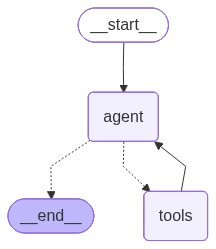

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11: Build and Compile the StateGraph
# ══════════════════════════════════════════════════════════════════════════════
#
# Graph structure:
#   START → agent → should_continue
#                       ↓ tools        ↓ __end__
#                    ToolNode ──────▶ agent (loop back)
#                                   END
#
# ToolNode (prebuilt) handles dispatching to the correct tool function
# based on the tool_call name emitted by the LLM.
# ══════════════════════════════════════════════════════════════════════════════

graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.set_entry_point("agent")

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "__end__": END},
)
graph_builder.add_edge("tools", "agent")

# Compile without checkpointer first (used for quick unit tests)
graph = graph_builder.compile()

print("✓ Graph compiled")
print("  START → agent → (tools → agent)* → END")

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12: Persistence (MemorySaver) and Streaming Helper
# ══════════════════════════════════════════════════════════════════════════════
#
# MemorySaver checkpoints state after each node, enabling:
#   - Resume after interruption (thread_id identifies the conversation)
#   - State inspection mid-run for debugging
#
# MAX_ITERATIONS caps the ReAct loop at 10 LangGraph steps. Each agent turn
# plus its corresponding tools turn counts as 2 steps, so 10 allows up to
# 5 full search-classify-act cycles — more than enough for the two-search pattern.
#
# run_agent_with_streaming displays each step as it executes, which is useful
# for verifying that transfer_player is being called and what the DB returned.
# ══════════════════════════════════════════════════════════════════════════════

memory = MemorySaver()
graph_with_memory = graph_builder.compile(checkpointer=memory)
MAX_ITERATIONS = 10

print(f"✓ Graph compiled with MemorySaver checkpointer")
print(f"✓ Max LangGraph steps: {MAX_ITERATIONS}")


def run_agent_with_streaming(query: str, thread_id: str = "run-1") -> None:
    """
    Run the agent with real-time streaming output.

    Streams each node event so you can see tool calls and results as they happen.
    Catches rate-limit errors and suggests a retry window.

    Args:
        query: Natural language task for the agent
        thread_id: Conversation identifier (change to start a fresh run)
    """
    print(f"\n{'='*70}")
    print(f"🤖 Agent Query: {query}")
    print(f"⚡ Rate limit: {rate_limiter.calls_per_minute} RPM | Max steps: {MAX_ITERATIONS}")
    print(f"{'='*70}\n")

    config = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": MAX_ITERATIONS,
    }
    initial = {
        "messages": [HumanMessage(content=query)],
        "detected_events": [],
        "portal_updates": [],
        "news_sources": NEWS_DOMAINS,
    }

    step = 0
    try:
        for event in graph_with_memory.stream(initial, config):
            step += 1
            for node_name, output in event.items():
                print(f"\n📍 Step {step}: {node_name.upper()}")
                print("-" * 50)
                if "messages" in output:
                    for msg in output["messages"]:
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            print("🔧 Tool calls:")
                            for tc in msg.tool_calls:
                                args_preview = json.dumps(tc['args'])[:120]
                                print(f"   - {tc['name']}({args_preview}...)")
                        elif hasattr(msg, 'content') and msg.content:
                            content = msg.content
                            if isinstance(content, str):
                                print(f"💬 {content[:600]}{'...' if len(content) > 600 else ''}")

        print(f"\n{'='*70}")
        print(f"✅ Completed ({rate_limiter.call_count} total API calls this session)")
        print(f"{'='*70}")

    except Exception as e:
        msg = str(e)
        if "429" in msg or "RESOURCE_EXHAUSTED" in msg or "quota" in msg.lower():
            import re as _re
            m = _re.search(r'retry in (\d+\.?\d*)', msg.lower())
            retry = float(m.group(1)) if m else 60
            print(f"\n⚠️  RATE LIMIT after {rate_limiter.call_count} calls — wait {retry:.0f}s")
            print(f"    https://ai.google.dev/aistudio/apikey")
        else:
            raise


def inspect_run(thread_id: str) -> None:
    """
    Inspect the persisted state for a completed run.

    Shows message count, portal_updates recorded, and the last few messages.
    """
    config = {"configurable": {"thread_id": thread_id}}
    state  = graph_with_memory.get_state(config)
    if not state.values:
        print(f"No state found for thread '{thread_id}'")
        return

    print(f"\n📊 State for thread '{thread_id}':")
    print("-" * 50)
    print(f"  Messages:      {len(state.values.get('messages', []))}")
    print(f"  Portal updates: {state.values.get('portal_updates', [])}")
    print(f"  News sources:  {state.values.get('news_sources', [])}")
    msgs = state.values.get('messages', [])
    if msgs:
        print(f"\n  Last {min(3, len(msgs))} messages:")
        for msg in msgs[-3:]:
            content = getattr(msg, 'content', '')
            if isinstance(content, str) and len(content) > 120:
                content = content[:120] + "..."
            print(f"    [{type(msg).__name__}] {content}")


print("✓ run_agent_with_streaming and inspect_run helpers defined")

✓ Graph compiled with MemorySaver checkpointer
✓ Max LangGraph steps: 10
✓ run_agent_with_streaming and inspect_run helpers defined


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13: Run — Transfer Portal Monitoring
# ══════════════════════════════════════════════════════════════════════════════
# Triggers the full two-search-classify-act loop.
#
# For each player_enters_portal event detected at >= 0.6 confidence, the agent
# will call transfer_player(), which writes to the DB:
#   - player_team_fit_scores.is_portal_candidate = True
#   - transfers.portal_entry_date (upsert)
#
# Requires GOOGLE_API_KEY and TAVILY_API_KEY in .env.
# ══════════════════════════════════════════════════════════════════════════════

if GOOGLE_API_KEY:
    run_agent_with_streaming(
        "Search for recent college basketball transfer portal news and update player availability.",
        thread_id="monitor-transfer-1",
    )
else:
    print("⚠️ GOOGLE_API_KEY not set — skipping agent run")


🤖 Agent Query: Search for recent college basketball transfer portal news and update player availability.
⚡ Rate limit: 12 RPM | Max steps: 10

🔄 API call #3 (7 messages in context)


2026-07-03 11:35:59,251 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"



📍 Step 1: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({"query": "college basketball transfer portal player enters portal"}...)
   - search_news({"query": "college basketball head coach leaves resigns fired departs"}...)
🔍 Tavily search: 'college basketball transfer portal player enters portal' | depth=advanced | domains=['247sports.com', 'espn.com', 'on3.com']
🔍 Tavily search: 'college basketball head coach leaves resigns fired departs' | depth=advanced | domains=['247sports.com', 'espn.com', 'on3.com']
✓ 10 results → 0 passed score filter (>= 0.5)
✓ 10 results → 0 passed score filter (>= 0.5)

📍 Step 2: TOOLS
--------------------------------------------------
💬 []
💬 []
⏳ Rate limit: waiting 4.0s...
🔄 API call #4 (10 messages in context)


2026-07-03 11:36:04,063 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"



📍 Step 3: AGENT
--------------------------------------------------

✅ Completed (4 total API calls this session)


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14: Run — Coaching Change Monitoring
# ══════════════════════════════════════════════════════════════════════════════
# Coach departures are logged via coach_departure() for manual review.
# No automatic DB writes happen — coaching changes need human judgment before
# any scheme profiles (Model 2) or downstream recommendations are updated.
# ══════════════════════════════════════════════════════════════════════════════

if GOOGLE_API_KEY:
    run_agent_with_streaming(
        "Check for any recent college basketball head coaching changes or departures.",
        thread_id="monitor-coaching-1",
    )
else:
    print("⚠️ GOOGLE_API_KEY not set — skipping agent run")


🤖 Agent Query: Check for any recent college basketball head coaching changes or departures.
⚡ Rate limit: 12 RPM | Max steps: 10

🔄 API call #5 (2 messages in context)


2026-07-03 11:36:25,231 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"



📍 Step 1: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({"query": "college basketball head coach leaves resigns fired departs"}...)
🔍 Tavily search: 'college basketball head coach leaves resigns fired departs' | depth=advanced | domains=['247sports.com', 'espn.com', 'on3.com']
✓ 10 results → 0 passed score filter (>= 0.5)

📍 Step 2: TOOLS
--------------------------------------------------
💬 []
⏳ Rate limit: waiting 4.2s...
🔄 API call #6 (4 messages in context)


2026-07-03 11:36:30,213 INFO HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"



📍 Step 3: AGENT
--------------------------------------------------

✅ Completed (6 total API calls this session)


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16: End-to-End DB Test — transfer_player against Real Database
# ══════════════════════════════════════════════════════════════════════════════
#
# HOW THIS TEST WORKS
# ─────────────────────────────────────────────────────────────────────────────
# 1. SETUP: Insert a sentinel test player + a player_team_fit_scores row with
#    is_portal_candidate = False. This simulates what the DB looks like for a
#    real player before they enter the portal.
#
# 2. CALL: Invoke transfer_player("Agent Test Player", "Test University").
#    The tool does two things:
#      a) UPDATE player_team_fit_scores SET is_portal_candidate = True
#         → player now appears in the recommendation engine's candidate pool
#         → recommendation SQL: WHERE ptf.is_portal_candidate = true
#      b) INSERT INTO transfers (portal_entry_date, from_school_id, season)
#         → records the portal entry event for audit / future Model 5 labels
#
# 3. VERIFY: Re-query both tables and assert the expected state.
#
# 4. CLEANUP: Delete all sentinel rows so the test is fully reversible.
#
# Sentinel IDs are far above real ingested data (~27k players, ~365 schools)
# and above the seed_test_data.py IDs (1-8, 42, 101, 9900xxx) to avoid
# any conflict with existing rows.
# ══════════════════════════════════════════════════════════════════════════════

if not _db_available:
    print("⚠️ portalpoint not importable — skipping DB test")
    print("   Run from repo root or install the package first")
else:
    from sqlalchemy import text as sql_text

    # ── Sentinel IDs (safe to insert and delete without touching real data) ───
    TEST_PLAYER_ID = 9_999_899  # BigInteger; above all real and seed IDs
    TEST_SCHOOL_ID = 9_900_301  # 'Test University' from seed_test_data (use 9_999_801 if not seeded)
    TEST_SEASON    = 2026

    engine = get_sync_engine()

    # ── Step 1: Setup ─────────────────────────────────────────────────────────
    # Insert a school if it doesn't exist yet (safe ON CONFLICT DO NOTHING).
    # Insert sentinel player. Insert a fit-score row with is_portal_candidate=False
    # to simulate the pre-portal state of a real player in the system.
    with engine.begin() as conn:
        conn.execute(
            sql_text("""
                INSERT INTO schools (id, name, conference, city, state, region)
                VALUES (:id, 'Test University', 'Test Conference', 'Testville', 'TS', 'Test Region')
                ON CONFLICT (id) DO NOTHING
            """),
            {"id": TEST_SCHOOL_ID},
        )

        conn.execute(
            sql_text("""
                INSERT INTO players (id, full_name, position, class_year, barttorvik_id)
                VALUES (:id, 'Agent Test Player', 'PG', 'jr', 'agent-test-player-v2')
                ON CONFLICT (id) DO NOTHING
            """),
            {"id": TEST_PLAYER_ID},
        )

        # player_team_fit_scores: pre-portal state (is_portal_candidate = False)
        # expires_at set 7 days out (matches the real pipeline default)
        conn.execute(
            sql_text("""
                INSERT INTO player_team_fit_scores
                    (player_id, school_id, season,
                     scheme_fit, gap_match, overall_fit,
                     role_fit, program_fit,
                     weight_gap, weight_scheme, weight_role, weight_program,
                     is_portal_candidate, model_version, expires_at)
                VALUES
                    (:player_id, :school_id, :season,
                     75.0, 68.0, 71.5,
                     0.0, 0.0,
                     0.20, 0.30, 0.25, 0.25,
                     false, 'agent-test-v2', NOW() + INTERVAL '7 days')
                ON CONFLICT (player_id, school_id, season)
                DO UPDATE SET is_portal_candidate = false
            """),
            {"player_id": TEST_PLAYER_ID, "school_id": TEST_SCHOOL_ID, "season": TEST_SEASON},
        )

    print("✓ Test rows inserted (player + fit-score row with is_portal_candidate=False)")

    # ── Step 2: Verify pre-test state ─────────────────────────────────────────
    with engine.connect() as conn:
        pre = conn.execute(
            sql_text(
                "SELECT is_portal_candidate, overall_fit FROM player_team_fit_scores "
                "WHERE player_id = :pid AND school_id = :sid"
            ),
            {"pid": TEST_PLAYER_ID, "sid": TEST_SCHOOL_ID},
        ).fetchone()

    print(f"\nBEFORE transfer_player call:")
    print(f"  is_portal_candidate = {pre.is_portal_candidate}   ← player NOT in recommendation pool")
    print(f"  overall_fit         = {pre.overall_fit}")

    # ── Step 3: Call the tool ─────────────────────────────────────────────────
    print("\nCalling transfer_player('Agent Test Player', 'Test University') ...")
    result = json.loads(
        transfer_player.invoke({
            "player_name": "Agent Test Player",
            "school_from": "Test University",
            "portal_entry_date": str(_date.today()),
        })
    )
    print(json.dumps(result, indent=2))

    # ── Step 4: Verify post-tool state ────────────────────────────────────────
    with engine.connect() as conn:
        post_fit = conn.execute(
            sql_text(
                "SELECT is_portal_candidate FROM player_team_fit_scores "
                "WHERE player_id = :pid AND school_id = :sid"
            ),
            {"pid": TEST_PLAYER_ID, "sid": TEST_SCHOOL_ID},
        ).fetchone()

        post_transfer = conn.execute(
            sql_text(
                "SELECT portal_entry_date, from_school_id, season FROM transfers "
                "WHERE player_id = :pid AND season = :season"
            ),
            {"pid": TEST_PLAYER_ID, "season": TEST_SEASON},
        ).fetchone()

    print(f"\nAFTER transfer_player call:")
    print(f"  is_portal_candidate  = {post_fit.is_portal_candidate}  ← player IS NOW in recommendation pool")
    if post_transfer:
        print(f"  portal_entry_date    = {post_transfer.portal_entry_date}")
        print(f"  from_school_id       = {post_transfer.from_school_id}")
        print(f"  season               = {post_transfer.season}")
    else:
        print("  transfers row        = NOT FOUND")

    # ── Step 5: Assertions ────────────────────────────────────────────────────
    assert result["success"] is True, f"transfer_player failed: {result}"
    assert post_fit.is_portal_candidate is True, \
        "FAIL: is_portal_candidate was NOT set to True in player_team_fit_scores!"
    assert post_transfer is not None, \
        "FAIL: No row was created in the transfers table!"
    assert str(post_transfer.portal_entry_date) == str(_date.today()), \
        f"FAIL: portal_entry_date mismatch: {post_transfer.portal_entry_date}"

    print("\n✅ All assertions passed!")
    print("   is_portal_candidate updated → player enters recommendation pool")
    print("   transfers row upserted      → portal entry date recorded")

    # ── Step 6: Cleanup ───────────────────────────────────────────────────────
    # Remove all sentinel rows so the test is fully reversible and safe to
    # re-run against any environment (dev, CI, staging).
    with engine.begin() as conn:
        conn.execute(sql_text("DELETE FROM transfers WHERE player_id = :pid"), {"pid": TEST_PLAYER_ID})
        conn.execute(sql_text("DELETE FROM player_team_fit_scores WHERE player_id = :pid"), {"pid": TEST_PLAYER_ID})
        conn.execute(sql_text("DELETE FROM players WHERE id = :pid"), {"pid": TEST_PLAYER_ID})
        # Only delete the school if WE inserted it (not if seed_test_data already had it)
        conn.execute(
            sql_text("DELETE FROM schools WHERE id = :sid AND name = 'Test University'"),
            {"sid": 9_999_801},  # only the truly sentinel school; 9900301 stays if seeded
        )

    print("🧹 Sentinel rows cleaned up — DB restored to pre-test state")

OperationalError: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5433 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5433 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15: Direct Tool Tests (no agent loop required)
# ══════════════════════════════════════════════════════════════════════════════
#
# Use this cell to validate individual tools independently of the full agent.
#   - search_news    → requires TAVILY_API_KEY
#   - classify tools → no API key needed (regex) or GOOGLE_API_KEY (LLM)
#   - transfer_player → requires DATABASE_URL (will return a structured error if unavailable)
#   - coach_departure → no DB; always succeeds as a log-only call
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("1. classify_events_batch (regex, no API key needed)")
print("-" * 60)

test_articles = [
    {
        "title": "Duke guard Marcus Bell enters NCAA transfer portal",
        "url": "https://247sports.com/article/marcus-bell-portal",
        "content": "Duke guard Marcus Bell has officially entered the NCAA transfer portal. The sophomore averaged 12.4 points per game.",
        "score": 0.92,
    },
    {
        "title": "Arizona head coach stepping down after eight seasons",
        "url": "https://espn.com/article/arizona-coach-departure",
        "content": "Arizona head coach Tom Bradley will step down at the end of the season after eight years with the program.",
        "score": 0.88,
    },
    {
        "title": "Kansas beats Kentucky in overtime thriller",
        "url": "https://espn.com/article/kansas-kentucky",
        "content": "Kansas edged Kentucky 78-75 in overtime in a non-conference clash.",
        "score": 0.55,
    },
]

batch_result = json.loads(
    classify_events_batch.invoke({"search_results_json": json.dumps(test_articles)})
)
print(f"Classified: {batch_result['articles_classified']} | Target events: {batch_result['target_events_found']}")
for c in batch_result["classifications"]:
    flag = "✅" if c["is_target_event"] else "⬜"
    print(f"  {flag} {c['event_type']:25s} conf={c['confidence']:.2f} | {c['title'][:55]}")


print("\n" + "=" * 60)
print("2. transfer_player (will succeed if DATABASE_URL is set, error otherwise)")
print("-" * 60)

# Using a fake player name to exercise the 'player not found' path safely.
# Replace with a real player name from the DB for a live end-to-end test.
tp_result = json.loads(
    transfer_player.invoke({
        "player_name": "Marcus Bell",
        "school_from": "Duke",
        "portal_entry_date": str(_date.today()),
    })
)
print(json.dumps(tp_result, indent=2))


print("\n" + "=" * 60)
print("3. coach_departure (log-only, no DB required)")
print("-" * 60)
cd_result = json.loads(
    coach_departure.invoke({"coach_name": "Tom Bradley", "school_from": "Arizona"})
)
print(json.dumps(cd_result, indent=2))